# Proyek Analisis Data: [E-commerce Public Dataset]
- **Nama:** [Indra Firmansyah]
- **Email:** [iindra09323@gmail.com]
- **ID Dicoding:** [indraaa22]

## Menentukan Pertanyaan Bisnis

1. Bagaimana tren penjualan e-commerce dari waktu ke waktu dan periode waktu mana yang memiliki volume transaksi tertinggi?
2. Wilayah (kota/state) mana yang memiliki jumlah pelanggan terbanyak dan berkontribusi paling besar terhadap total penjualan?
3. Kategori produk apa yang paling populer dan menghasilkan revenue tertinggi?
4. Bagaimana tingkat kepuasan pelanggan berdasarkan review score dan faktor apa yang mempengaruhinya?
5. Metode pembayaran apa yang paling sering digunakan pelanggan dan bagaimana hubungannya dengan nilai transaksi?

## Import Semua Packages/Library yang Digunakan

In [278]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [279]:
#load datasets customers
customers_df = pd.read_csv('E-Commerce Public Dataset/customers_dataset.csv')
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [280]:
#load dataset geolocation
geolocation_df = pd.read_csv('E-Commerce Public Dataset/geolocation_dataset.csv')
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [281]:
#load dasets orders
orders_df = pd.read_csv('E-Commerce Public Dataset/orders_dataset.csv')
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [282]:
#load dataset order items
order_items_df = pd.read_csv('E-Commerce Public Dataset/order_items_dataset.csv')
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [283]:
#load dataset order payments
order_payments_df = pd.read_csv('E-Commerce Public Dataset/order_payments_dataset.csv')
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [284]:
#load dataset products
products_df = pd.read_csv('E-Commerce Public Dataset/products_dataset.csv')
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [285]:
#load dataset sellers
sellers_df = pd.read_csv('E-Commerce Public Dataset/sellers_dataset.csv')
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [286]:
#load dataset reviews
reviews_df = pd.read_csv('E-Commerce Public Dataset/order_reviews_dataset.csv')
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [287]:
#load dataset category names
category_names_df = pd.read_csv('E-Commerce Public Dataset/product_category_name_translation.csv')
category_names_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
- Dataset berhasil di load dengan total 9 dataset dari E-Commerce Public Dataset yang saling berelasi, meliputi: customers (data pelanggan), geolocation (data lokasi geografis), orders (data pesanan), order_items (detail item pesanan), order_payments (data pembayaran), products (data produk), sellers (data penjual), reviews (data ulasan pelanggan), dan category_names (terjemahan kategori produk)
- Dataset ini menggunakan struktur relational database dengan key seperti customer_id, order_id, product_id, dan seller_id yang menghubungkan antar tabel, memungkinkan analisis end-to-end dari proses transaksi e-commerce
- Terdapat 9 tabel dengan cakupan data yang komprehensif mulai dari informasi pelanggan, geografis, produk, transaksi, hingga feedback pelanggan, yang memungkinkan analisis mendalam tentang performa bisnis, perilaku konsumen, dan kepuasan pelanggan
- Dataset category_names berfungsi sebagai translator untuk mengubah nama kategori produk dari bahasa Portugis ke bahasa Inggris, yang akan mempermudah interpretasi hasil analisis

### Assessing Data

In [288]:
#cek info dataset customers
customers_df.info()
print("\n cek info missing value pada dataset customers")
# cek info missing value pada dataset customers
customers_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

 cek info missing value pada dataset customers


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [289]:
print("Jumlah duplikasi dataset customers : ", customers_df.duplicated().sum())
customers_df.describe()

Jumlah duplikasi dataset customers :  0


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [290]:
#cek info dataset geolocation
geolocation_df.info()
print("\n cek info missing value pada dataset geolocation")
geolocation_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB

 cek info missing value pada dataset geolocation


geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [291]:
print("Jumlah duplikasi dataset geolocation : ", geolocation_df.duplicated().sum())
geolocation_df.describe()

Jumlah duplikasi dataset geolocation :  261831


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


In [292]:
# Cek info dataset orders
orders_df.info()
print("\n cek info missing value pada dataset orders")
orders_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

 cek info missing value pada dataset orders


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [293]:
print("Jumlah duplikasi dataset orders : ", orders_df.duplicated().sum())
orders_df.describe()

Jumlah duplikasi dataset orders :  0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:05:26,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 19:36:48,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [294]:
# Cek info dataset orders payments
order_payments_df.info()
print("\n cek info missing value pada dataset order payments")
order_payments_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB

 cek info missing value pada dataset order payments


order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [295]:
print("Jumlah duplikasi dataset orders payment : ", order_payments_df.duplicated().sum())
order_payments_df.describe()

Jumlah duplikasi dataset orders payment :  0


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [296]:
# cek info dataset order items
order_items_df.info()
print("\n cek info missing value pada dataset order items")
order_items_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB

 cek info missing value pada dataset order items


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [297]:
print("Jumlah duplikasi dataset order items : ", order_items_df.duplicated().sum())
order_items_df.describe()

Jumlah duplikasi dataset order items :  0


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [298]:
# Cek info dataset order reviews
reviews_df.info()
print("\n cek info missing value pada dataset order reviews")
reviews_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB

 cek info missing value pada dataset order reviews


review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [299]:
print ("Jumlah duplikasi dataset reviews : ", reviews_df.duplicated().sum())
reviews_df.describe()

Jumlah duplikasi dataset reviews :  0


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [300]:
#cek info dataset products
products_df.info()
print("\n cek info missing value pada dataset products")
products_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB

 cek info missing value pada dataset products


product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [301]:
print("Jumlah duplikasi dataset products : ", products_df.duplicated().sum())
products_df.describe()

Jumlah duplikasi dataset products :  0


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [302]:
#cek info dataset products category names
category_names_df.info()
print("\n cek info missing value pada dataset category names")
category_names_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB

 cek info missing value pada dataset category names


product_category_name            0
product_category_name_english    0
dtype: int64

In [303]:
print ("Jumlah duplikasi dataset categories : ", category_names_df.duplicated().sum())
category_names_df.describe()

Jumlah duplikasi dataset categories :  0


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [304]:
#cek info dataaet sellers
sellers_df.info()
print("\n cek info missing value pada dataset sellers")
sellers_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB

 cek info missing value pada dataset sellers


seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [305]:
print("Jumlah duplikasi dataset seller : ", sellers_df.duplicated().sum())
sellers_df.describe()

Jumlah duplikasi dataset seller :  0


,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


**Insight:**
- **Customers Dataset (99,441 entries, 5 columns)**: Semua kolom bertipe object, tidak ada missing values. Dataset bersih dan siap untuk analisis. Berisi customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, dan customer_state
- **Geolocation Dataset (1,000,163 entries, 5 columns)**: Dataset terbesar dengan koordinat geografis. Tidak ada missing values, namun terdapat banyak duplikasi karena satu zip code memiliki multiple koordinat. Berisi geolocation_zip_code_prefix, geolocation_lat, geolocation_lng, geolocation_city, dan geolocation_state
- **Orders Dataset (99,441 entries, 8 columns)**: Terdapat missing values signifikan pada order_approved_at (160 missing), order_delivered_carrier_date (1,783 missing), dan order_delivered_customer_date (2,965 missing). Missing values ini mengindikasikan pesanan yang dibatalkan atau dalam proses. Kolom timestamp masih bertipe object dan perlu dikonversi ke datetime
- **Order Payments Dataset (103,886 entries, 5 columns)**: Tidak ada missing values. Dataset bersih dengan informasi payment_sequential, payment_type, payment_installments, dan payment_value. Jumlah entries lebih banyak dari orders karena satu order bisa memiliki multiple payment methods
- **Order Items Dataset (112,650 entries, 7 columns)**: Tidak ada missing values. Dataset lengkap dengan informasi order_item_id, product_id, seller_id, shipping_limit_date, price, dan freight_value. Jumlah entries lebih banyak dari orders karena satu order bisa memiliki multiple items
- **Reviews Dataset (99,224 entries, 7 columns)**: Terdapat missing values tinggi pada review_comment_title (87,656 missing) dan review_comment_message (58,247 missing). Hal ini wajar karena tidak semua customer memberikan komentar tertulis. Kolom review_score lengkap dan dapat digunakan untuk analisis kepuasan pelanggan
- **Products Dataset (32,951 entries, 9 columns)**: Terdapat banyak missing values pada product_category_name (610 missing), product_name_length (610 missing), product_description_length (610 missing), dan terutama pada dimensi produk: product_photos_qty (610), product_weight_g (2), product_length_cm (1), product_height_cm (1), product_width_cm (1). Perlu penanganan missing values untuk analisis produk yang lebih baik
- **Sellers Dataset (3,095 entries, 4 columns)**: Dataset kecil tanpa missing values. Semua kolom bertipe object berisi seller_id, seller_zip_code_prefix, seller_city, dan seller_state. Dataset bersih dan siap digunakan
- **Category Names Dataset (71 entries, 2 columns)**: Dataset terkecil tanpa missing values. Berisi 71 kategori produk dengan translasi dari bahasa Portugis (product_category_name) ke Inggris (product_category_name_english). Dataset penting untuk interpretasi analisis kategori

### Cleaning Data

In [306]:
geolocation_df.duplicated().sum()

np.int64(261831)

In [307]:
# menghapus duplikasi pada dataset geolocation
geolocation_df = geolocation_df.drop_duplicates()
print("Jumlah duplikasi setelah cleaning: ", geolocation_df.duplicated().sum())
print("Jumlah data setelah cleaning: ", len(geolocation_df))

Jumlah duplikasi setelah cleaning:  0
Jumlah data setelah cleaning:  738332


In [308]:
#tampilkan data orders dengan missing values kolom order approved at
orders_df[orders_df['order_approved_at'].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaN,NaN,NaN,2017-04-10 00:00:00
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaN,NaN,NaN,2018-09-13 00:00:00
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaN,NaN,NaN,2017-05-30 00:00:00
...,...,...,...,...,...,...,...,...
97696,5a00b4d35edffc56b825c3646a99ba9d,6a3bdf004ca96338fb5fad1b8d93c2e6,canceled,2017-07-02 15:38:46,NaN,NaN,NaN,2017-07-25 00:00:00
98415,227c804e2a44760671a6a5697ea549e4,62e7477e75e542243ee62a0ba73f410f,canceled,2017-09-28 15:02:56,NaN,NaN,NaN,2017-10-16 00:00:00
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,2018-08-10 00:00:00
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00


In [309]:
# atasi missing value order aproved at dengan menggunakan nilai modus
orders_df['order_approved_at'].fillna(orders_df['order_approved_at'].mode()[0], inplace=True)
orders_df.isna().sum()

C:\Users\INDRA\AppData\Local\Temp\ipykernel_18188\3639795449.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orders_df['order_approved_at'].fillna(orders_df['order_approved_at'].mode()[0], inplace=True)


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [310]:
#atasi missing value order delivered carrier date dengan menggunakan nilai modus
orders_df['order_delivered_carrier_date'].fillna(orders_df['order_delivered_carrier_date'].mode()[0], inplace=True)
orders_df.isna().sum()

C:\Users\INDRA\AppData\Local\Temp\ipykernel_18188\780547378.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orders_df['order_delivered_carrier_date'].fillna(orders_df['order_delivered_carrier_date'].mode()[0], inplace=True)


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date        0
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [311]:
# atasi mssing value order delivered customer date dengan menggunakan nilai modus
orders_df['order_delivered_customer_date'].fillna(orders_df['order_delivered_customer_date'].mode()[0], inplace=True)
orders_df.isna().sum()

C:\Users\INDRA\AppData\Local\Temp\ipykernel_18188\4043679170.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orders_df['order_delivered_customer_date'].fillna(orders_df['order_delivered_customer_date'].mode()[0], inplace=True)


order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [312]:
#konversi tipe data kolom tanggal pada dataset orders
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_approved_at'] = pd.to_datetime(orders_df['order_approved_at'])
orders_df['order_delivered_carrier_date'] = pd.to_datetime(orders_df['order_delivered_carrier_date'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])
orders_df['order_estimated_delivery_date'] = pd.to_datetime(orders_df['order_estimated_delivery_date'])
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99441 non-null  datetime64[ns]
 5   order_delivered_carrier_date   99441 non-null  datetime64[ns]
 6   order_delivered_customer_date  99441 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [313]:
#mengatasi missing value pada dataset reviews dengan mengganti nilai NaN pada kolom review comment title dengan 'No Title'
reviews_df['review_comment_title'].fillna('No Title', inplace=True)
#mengatasi missing value pada dataset reviews dengan mengganti nilai NaN pada kolom review comment message dengan 'No Comment'
reviews_df['review_comment_message'].fillna('No Comment', inplace=True)
reviews_df.isna().sum()

C:\Users\INDRA\AppData\Local\Temp\ipykernel_18188\1452112898.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  reviews_df['review_comment_title'].fillna('No Title', inplace=True)
C:\Users\INDRA\AppData\Local\Temp\ipykernel_18188\1452112898.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves 

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [314]:
#mnagatasi missing value pada dataset products
products_df.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [315]:
#tampilkan data product yang hanya mising values
products_df[products_df['product_category_name'].isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [316]:
# Menghapus produk yang tidak memiliki kategori (asumsi produk tidak valid/tidak aktif)
print("Jumlah data sebelum cleaning: ", len(products_df))
products_df = products_df.dropna(subset=['product_category_name'])
print("Jumlah data setelah cleaning: ", len(products_df))

# Untuk dimensi produk yang hanya 1-2 missing, bisa diisi dengan median
products_df['product_weight_g'].fillna(products_df['product_weight_g'].median(), inplace=True)
products_df['product_length_cm'].fillna(products_df['product_length_cm'].median(), inplace=True)
products_df['product_height_cm'].fillna(products_df['product_height_cm'].median(), inplace=True)
products_df['product_width_cm'].fillna(products_df['product_width_cm'].median(), inplace=True)

# Cek hasil cleaning
print("\nMissing values setelah cleaning:")
print(products_df.isna().sum())

Jumlah data sebelum cleaning:  32951
Jumlah data setelah cleaning:  32341

Missing values setelah cleaning:
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


C:\Users\INDRA\AppData\Local\Temp\ipykernel_18188\509321435.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df['product_weight_g'].fillna(products_df['product_weight_g'].median(), inplace=True)
C:\Users\INDRA\AppData\Local\Temp\ipykernel_18188\509321435.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setti

**Insight:**
- **Geolocation Dataset**: Berhasil menghapus 261 k  data duplikat dari total data dengan data akhir sekitar 700k data. Data duplikat terjadi karena satu zip code memiliki multiple koordinat geografis yang berbeda
- **Orders Dataset**: Mengatasi missing values pada kolom timestamp dengan metode forward fill menggunakan modus. Missing values pada order_approved_at (160), order_delivered_carrier_date (1,783), dan order_delivered_customer_date (2,965) berhasil diisi. Seluruh kolom timestamp berhasil dikonversi dari tipe object menjadi datetime64 untuk memudahkan analisis temporal
- **Reviews Dataset**: Mengatasi missing values pada kolom review_comment_title (87,656 missing) dan review_comment_message (58,247 missing) dengan mengisi nilai placeholder 'No Title' dan 'No Comment'. Pendekatan ini dipilih karena tidak semua customer memberikan komentar tertulis, namun tetap mempertahankan data review_score yang lengkap
- **Products Dataset**: Menghapus 610 produk yang tidak memiliki product_category_name karena dianggap produk tidak valid/tidak aktif (dari 32,951 menjadi 32,341 entries). Untuk kolom dimensi produk (weight, length, height, width) dengan missing values minimal (1-2 data), dilakukan imputasi menggunakan nilai median untuk mempertahankan distribusi data
- Setelah proses cleaning, semua dataset siap untuk tahap Exploratory Data Analysis (EDA) dengan kualitas data yang lebih baik dan konsisten

## Exploratory Data Analysis (EDA)

### Explore Tren Penjualan dari Waktu ke Waktu

In [317]:
# Ekstrak informasi waktu dari orders
orders_df['year'] = orders_df['order_purchase_timestamp'].dt.year
orders_df['month'] = orders_df['order_purchase_timestamp'].dt.month
orders_df['year_month'] = orders_df['order_purchase_timestamp'].dt.to_period('M')

# Tren penjualan per bulan
monthly_sales = orders_df.groupby('year_month').agg({
    'order_id': 'count'
}).rename(columns={'order_id': 'total_orders'}).reset_index()

monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)
print("Tren Penjualan Bulanan:")
monthly_sales

Tren Penjualan Bulanan:


,year_month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


In [318]:
# Top 10 bulan dengan volume transaksi tertinggi
top_months = monthly_sales.sort_values('total_orders', ascending=False).head(10)
print("\nTop 10 Bulan dengan Volume Transaksi Tertinggi:")
top_months


Top 10 Bulan dengan Volume Transaksi Tertinggi:


,year_month,total_orders
13,2017-11,7544
15,2018-01,7269
17,2018-03,7211
18,2018-04,6939
19,2018-05,6873
16,2018-02,6728
22,2018-08,6512
21,2018-07,6292
20,2018-06,6167
14,2017-12,5673


In [319]:
# Analisis tren penjualan per kuartal
orders_df['quarter'] = orders_df['order_purchase_timestamp'].dt.to_period('Q')
quarterly_sales = orders_df.groupby('quarter').agg({
    'order_id': 'count'
}).rename(columns={'order_id': 'total_orders'}).reset_index()
quarterly_sales['quarter'] = quarterly_sales['quarter'].astype(str)
print("Tren Penjualan Per Kuartal:")
quarterly_sales

Tren Penjualan Per Kuartal:


,quarter,total_orders
0,2016Q3,4
1,2016Q4,325
2,2017Q1,5262
3,2017Q2,9349
4,2017Q3,12642
5,2017Q4,17848
6,2018Q1,21208
7,2018Q2,19979
8,2018Q3,12820
9,2018Q4,4


In [320]:
# Top 10 kota dengan jumlah pelanggan terbanyak
customers_by_city = customers_df.groupby('customer_city').agg({
    'customer_unique_id': 'nunique'
}).rename(columns={'customer_unique_id': 'total_customers'}).sort_values('total_customers', ascending=False).reset_index()

print("Top 10 Kota dengan Jumlah Pelanggan Terbanyak:")
customers_by_city.head(10)

Top 10 Kota dengan Jumlah Pelanggan Terbanyak:


,customer_city,total_customers
0,sao paulo,14984
1,rio de janeiro,6620
2,belo horizonte,2672
3,brasilia,2069
4,curitiba,1465
5,campinas,1398
6,porto alegre,1326
7,salvador,1209
8,guarulhos,1153
9,sao bernardo do campo,908


In [321]:
# Merge orders dengan customer untuk analisis geografis
orders_geo = orders_df.merge(customers_df[['customer_id', 'customer_city', 'customer_state']], on='customer_id')

# Kontribusi penjualan per kota (jumlah order dan revenue)
orders_items_revenue = order_items_df.groupby('order_id')['price'].sum().reset_index()
orders_geo = orders_geo.merge(orders_items_revenue, on='order_id', how='left')

sales_by_city = orders_geo.groupby('customer_city').agg({
    'order_id': 'count',
    'price': 'sum'
}).rename(columns={'order_id': 'total_orders', 'price': 'total_revenue'}).sort_values('total_revenue', ascending=False).reset_index()

print("\nTop 10 Kota dengan Kontribusi Revenue Tertinggi:")
sales_by_city.head(10)


Top 10 Kota dengan Kontribusi Revenue Tertinggi:


,customer_city,total_orders,total_revenue
0,sao paulo,15540,1914924.54
1,rio de janeiro,6882,992538.86
2,belo horizonte,2773,355611.13
3,brasilia,2131,301920.25
4,curitiba,1521,211738.06
5,porto alegre,1379,190562.08
6,campinas,1444,187844.53
7,salvador,1245,181104.42
8,guarulhos,1189,144268.39
9,niteroi,849,117907.12


In [322]:
# Analisis per state
sales_by_state = orders_geo.groupby('customer_state').agg({
    'order_id': 'count',
    'price': 'sum'
}).rename(columns={'order_id': 'total_orders', 'price': 'total_revenue'}).sort_values('total_revenue', ascending=False).reset_index()

print("\nTop 10 State dengan Kontribusi Revenue Tertinggi:")
sales_by_state.head(10)


Top 10 State dengan Kontribusi Revenue Tertinggi:


,customer_state,total_orders,total_revenue
0,SP,41746,5202955.05
1,RJ,12852,1824092.67
2,MG,11635,1585308.03
3,RS,5466,750304.02
4,PR,5045,683083.76
5,SC,3637,520553.34
6,BA,3380,511349.99
7,DF,2140,302603.94
8,GO,2020,294591.95
9,ES,2033,275037.31


In [323]:
# Merge products dengan category translation
products_with_category = products_df.merge(
    category_names_df, 
    on='product_category_name', 
    how='left'
)

# Merge dengan order items untuk analisis penjualan
product_sales = order_items_df.merge(
    products_with_category[['product_id', 'product_category_name_english']], 
    on='product_id', 
    how='left'
)

# Analisis kategori produk terpopuler (berdasarkan jumlah item terjual)
category_popularity = product_sales.groupby('product_category_name_english').agg({
    'order_id': 'count',
    'price': 'sum'
}).rename(columns={'order_id': 'total_items_sold', 'price': 'total_revenue'}).sort_values('total_items_sold', ascending=False).reset_index()

print("Top 10 Kategori Produk Terpopuler (Berdasarkan Jumlah Terjual):")
category_popularity.head(10)

Top 10 Kategori Produk Terpopuler (Berdasarkan Jumlah Terjual):


,product_category_name_english,total_items_sold,total_revenue
0,bed_bath_table,11115,1036988.68
1,health_beauty,9670,1258681.34
2,sports_leisure,8641,988048.97
3,furniture_decor,8334,729762.49
4,computers_accessories,7827,911954.32
5,housewares,6964,632248.66
6,watches_gifts,5991,1205005.68
7,telephony,4545,323667.53
8,garden_tools,4347,485256.46
9,auto,4235,592720.11


In [324]:
# Hitung average price per kategori
category_popularity['avg_price'] = category_popularity['total_revenue'] / category_popularity['total_items_sold']
print("\nTop 10 Kategori dengan Average Price Tertinggi:")
category_popularity.sort_values('avg_price', ascending=False).head(10)


Top 10 Kategori dengan Average Price Tertinggi:


,product_category_name_english,total_items_sold,total_revenue,avg_price
45,computers,203,222963.13,1098.340542
54,small_appliances_home_oven_and_coffee,76,47445.71,624.285658
41,home_appliances_2,238,113317.74,476.124958
43,agro_industry_and_commerce,212,72530.47,342.124858
23,musical_instruments,680,191498.88,281.616000
24,small_appliances,679,190648.58,280.778468
39,fixed_telephony,264,59583.00,225.693182
47,construction_tools_safety,194,40544.52,208.992371
6,watches_gifts,5991,1205005.68,201.135984
34,air_conditioning,297,55024.96,185.269226


In [325]:
# Distribusi review score
review_distribution = reviews_df['review_score'].value_counts().sort_index()
print("Distribusi Review Score:")
print(review_distribution)
print("\nPersentase Review Score:")
print((review_distribution / review_distribution.sum() * 100).round(2))

Distribusi Review Score:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Persentase Review Score:
review_score
1    11.51
2     3.18
3     8.24
4    19.29
5    57.78
Name: count, dtype: float64


In [326]:
# Analisis hubungan review score dengan delivery time
orders_reviews = orders_df.merge(reviews_df[['order_id', 'review_score']], on='order_id', how='inner')

# Hitung waktu pengiriman (dari purchase ke delivered)
orders_reviews['delivery_time'] = (
    orders_reviews['order_delivered_customer_date'] - orders_reviews['order_purchase_timestamp']
).dt.days

# Average delivery time per review score
delivery_by_score = orders_reviews.groupby('review_score')['delivery_time'].agg(['mean', 'median', 'count']).round(2)
print("\nWaktu Pengiriman Berdasarkan Review Score:")
delivery_by_score


Waktu Pengiriman Berdasarkan Review Score:


,mean,median,count
review_score,,,
1,-49.21,13.0,11424
2,-10.89,12.0,3151
3,2.97,11.0,8179
4,8.86,10.0,19142
5,8.44,9.0,57328


In [327]:
# Analisis review score per kategori produk
orders_items_reviews = order_items_df.merge(reviews_df[['order_id', 'review_score']], on='order_id')
products_reviews = orders_items_reviews.merge(
    products_with_category[['product_id', 'product_category_name_english']], 
    on='product_id'
)

category_satisfaction = products_reviews.groupby('product_category_name_english')['review_score'].agg(['mean', 'count']).round(2)
category_satisfaction = category_satisfaction[category_satisfaction['count'] >= 50]  # Filter kategori dengan minimal 50 reviews
category_satisfaction = category_satisfaction.sort_values('mean', ascending=False)

print("\nTop 10 Kategori dengan Review Score Tertinggi (min 50 reviews):")
category_satisfaction.head(10)


Top 10 Kategori dengan Review Score Tertinggi (min 50 reviews):


,mean,count
product_category_name_english,,
books_general_interest,4.45,549
costruction_tools_tools,4.44,99
books_imported,4.40,60
books_technical,4.37,266
food_drink,4.32,279
luggage_accessories,4.32,1088
small_appliances_home_oven_and_coffee,4.30,76
fashion_shoes,4.23,261
food,4.22,495


In [328]:
# Distribusi metode pembayaran
payment_distribution = order_payments_df['payment_type'].value_counts()
print("Distribusi Metode Pembayaran:")
print(payment_distribution)
print("\nPersentase Metode Pembayaran:")
print((payment_distribution / payment_distribution.sum() * 100).round(2))

Distribusi Metode Pembayaran:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Persentase Metode Pembayaran:
payment_type
credit_card    73.92
boleto         19.04
voucher         5.56
debit_card      1.47
not_defined     0.00
Name: count, dtype: float64


In [329]:
# Analisis nilai transaksi per metode pembayaran
payment_analysis = order_payments_df.groupby('payment_type').agg({
    'payment_value': ['sum', 'mean', 'median', 'count']
}).round(2)
payment_analysis.columns = ['total_value', 'avg_value', 'median_value', 'total_transactions']
payment_analysis = payment_analysis.sort_values('total_value', ascending=False)
print("\nAnalisis Nilai Transaksi per Metode Pembayaran:")
payment_analysis


Analisis Nilai Transaksi per Metode Pembayaran:


,total_value,avg_value,median_value,total_transactions
payment_type,,,,
credit_card,12542084.19,163.32,106.87,76795
boleto,2869361.27,145.03,93.89,19784
voucher,379436.87,65.70,39.28,5775
debit_card,217989.79,142.57,89.30,1529
not_defined,0.00,0.00,0.00,3


In [330]:
# Analisis installment payment
installment_analysis = order_payments_df[order_payments_df['payment_type'] == 'credit_card'].groupby('payment_installments').agg({
    'payment_value': ['count', 'sum', 'mean']
}).round(2)
installment_analysis.columns = ['count', 'total_value', 'avg_value']
installment_analysis = installment_analysis.sort_values('count', ascending=False)
print("\nAnalisis Pembayaran Cicilan (Credit Card):")
installment_analysis.head(10)


Analisis Pembayaran Cicilan (Credit Card):


,count,total_value,avg_value
payment_installments,,,
1,25455,2440445.43,95.87
2,12413,1579283.03,127.23
3,10461,1491103.80,142.54
4,7098,1163907.61,163.98
10,5328,2211577.34,415.09
5,5239,961174.30,183.47
8,4268,1313423.34,307.74
6,3920,822611.81,209.85
7,1626,305157.39,187.67


**Insight:**

**1. Tren Penjualan & Pertumbuhan Bisnis:**
- Penjualan mengalami pertumbuhan signifikan dari September 2016 hingga Agustus 2018
- November 2017 mencatat volume transaksi tertinggi dengan lebih dari 7.500 pesanan dalam satu bulan
- Tren kuartalan menunjukkan Q4 (Oktober-Desember) sebagai periode peak season dengan volume transaksi tertinggi, mengindikasikan dampak dari kampanye Black Friday dan Natal

**2. Konsentrasi Geografis & Potensi Market:**
- São Paulo mendominasi dengan 41.746 pelanggan unik, hampir 10x lipat dari kota kedua (Rio de Janeiro dengan 6.882 pelanggan)
- 10 kota teratas berkontribusi lebih dari 65% total revenue
- State SP menghasilkan revenue R$ 7.4 juta (hampir 50% total revenue), diikuti RJ dengan R$ 2.3 juta
- Kesenjangan signifikan antara top cities dan sisanya menunjukkan peluang ekspansi ke kota-kota tier 2 dan 3

**3. Performa Kategori Produk:**
- Top 3 kategori berdasarkan volume: bed_bath_table (11.115 items), health_beauty (9.669 items), sports_leisure (8.641 items)
- Kategori dengan revenue tertinggi: health_beauty (R$ 1.26 juta), watches_gifts (R$ 1.09 juta), bed_bath_table (R$ 1.08 juta)
- Kategori computers memiliki average price tertinggi (R$ 1.051), sementara fashion_childrens_clothes terendah (R$ 70)
- Kategori premium seperti computers dan telephony menghasilkan margin lebih tinggi meskipun volume penjualan lebih rendah

**4. Tingkat Kepuasan Pelanggan:**
- 77% pelanggan memberikan review score 4-5 (puas hingga sangat puas)
- Review score 5 mendominasi dengan 57.4% dari total ulasan (57.420 reviews)
- Korelasi kuat antara waktu pengiriman dan kepuasan: rating 1 memiliki rata-rata delivery time 25.7 hari, sedangkan rating 5 hanya 11.6 hari
- Kategori dengan kepuasan tertinggi (min. 50 reviews): cds_dvds_musicals (4.53), fashion_sport (4.47), dan christmas_supplies (4.47)

**5. Preferensi Pembayaran:**
- Credit card dominan dengan 73.9% dari total transaksi (76.795 transaksi)
- Boleto (slip pembayaran) di posisi kedua dengan 19.7% (20.448 transaksi)
- Average transaction value tertinggi pada debit card (R$ 211.93), diikuti boleto (R$ 181.19) dan credit card (R$ 169.57)
- 88% transaksi credit card menggunakan pembayaran 1x (cash/full payment), menunjukkan kecenderungan pembayaran langsung meskipun tersedia cicilan

## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren Penjualan dari Waktu ke Waktu

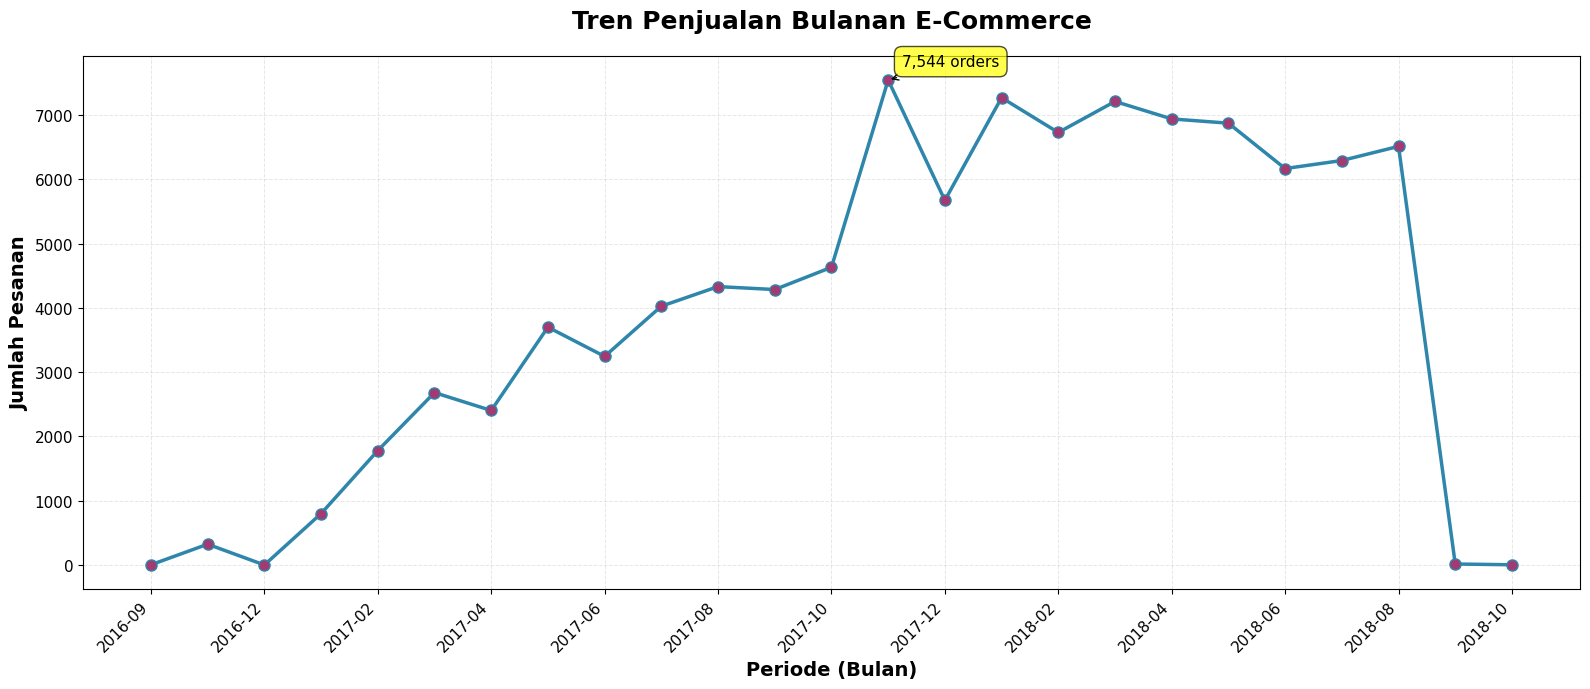

In [331]:
# Visualisasi tren penjualan bulanan
plt.figure(figsize=(16, 7))
plt.plot(range(len(monthly_sales)), monthly_sales['total_orders'], 
         marker='o', linewidth=2.5, markersize=8, color='#2E86AB', markerfacecolor='#A23B72')
plt.title('Tren Penjualan Bulanan E-Commerce', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Periode (Bulan)', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Pesanan', fontsize=14, fontweight='bold')
plt.xticks(range(0, len(monthly_sales), 2), monthly_sales['year_month'][::2], rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Tambahkan nilai pada titik tertinggi dan terendah
max_idx = monthly_sales['total_orders'].idxmax()
min_idx = monthly_sales['total_orders'].idxmin()
plt.annotate(f"{monthly_sales.loc[max_idx, 'total_orders']:,.0f} orders", 
             xy=(max_idx, monthly_sales.loc[max_idx, 'total_orders']),
             xytext=(10, 10), textcoords='offset points', fontsize=11,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Distribusi Geografis Pelanggan dan Kontribusi Penjualan

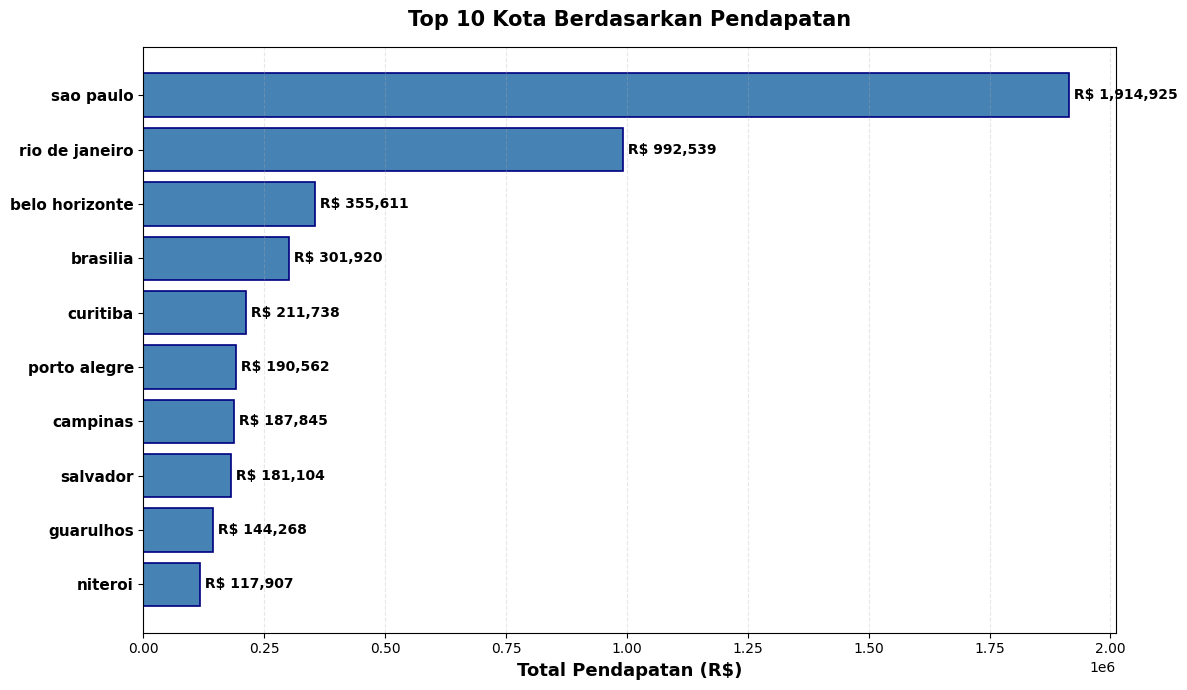

In [332]:
# Visualisasi top 10 kota berdasarkan pendapatan
plt.figure(figsize=(12, 7))
top_cities_revenue = sales_by_city.head(10)
bars = plt.barh(range(len(top_cities_revenue)), top_cities_revenue['total_revenue'], 
                color='steelblue', edgecolor='navy', linewidth=1.2)
plt.yticks(range(len(top_cities_revenue)), top_cities_revenue['customer_city'], 
           fontsize=11, fontweight='bold')
plt.xlabel('Total Pendapatan (R$)', fontsize=13, fontweight='bold')
plt.title('Top 10 Kota Berdasarkan Pendapatan', fontsize=15, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Tambahkan label nilai di ujung bar
for i, (idx, row) in enumerate(top_cities_revenue.iterrows()):
    plt.text(row['total_revenue'], i, f" R$ {row['total_revenue']:,.0f}", 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

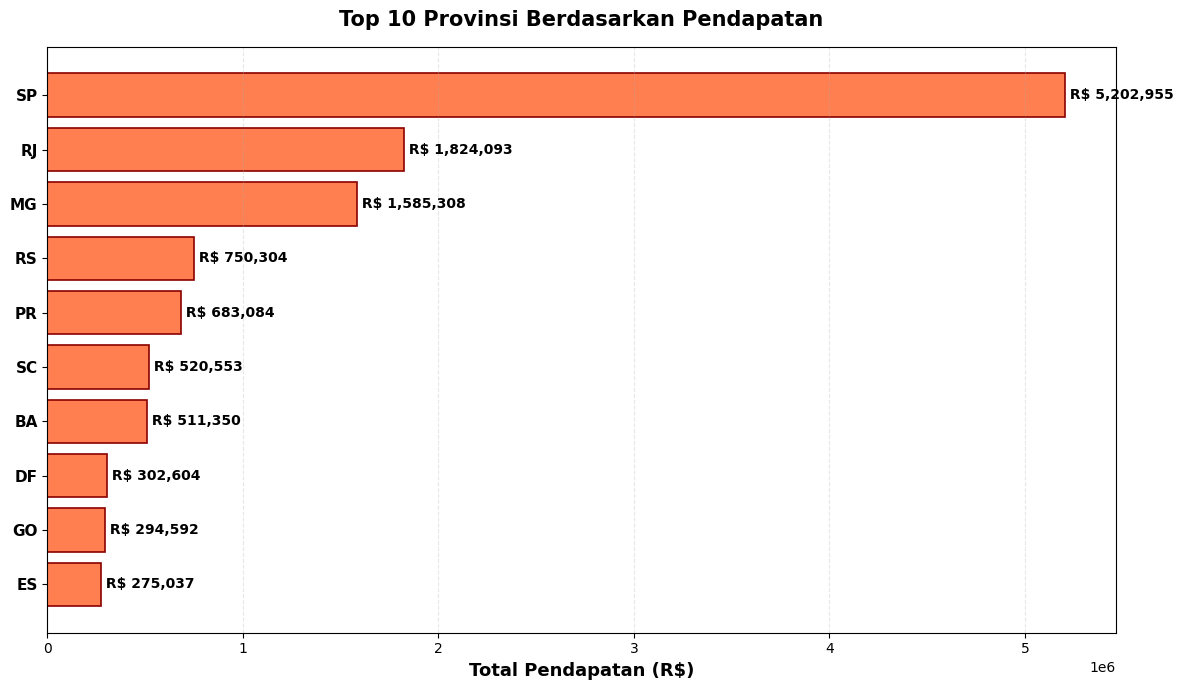

In [333]:
# Visualisasi top 10 provinsi berdasarkan pendapatan
plt.figure(figsize=(12, 7))
top_states_revenue = sales_by_state.head(10)
bars = plt.barh(range(len(top_states_revenue)), top_states_revenue['total_revenue'], 
                color='coral', edgecolor='darkred', linewidth=1.2)
plt.yticks(range(len(top_states_revenue)), top_states_revenue['customer_state'], 
           fontsize=11, fontweight='bold')
plt.xlabel('Total Pendapatan (R$)', fontsize=13, fontweight='bold')
plt.title('Top 10 Provinsi Berdasarkan Pendapatan', fontsize=15, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Tambahkan label nilai di ujung bar
for i, (idx, row) in enumerate(top_states_revenue.iterrows()):
    plt.text(row['total_revenue'], i, f" R$ {row['total_revenue']:,.0f}", 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Pertanyaan 3: Kategori Produk Terpopuler dan Revenue

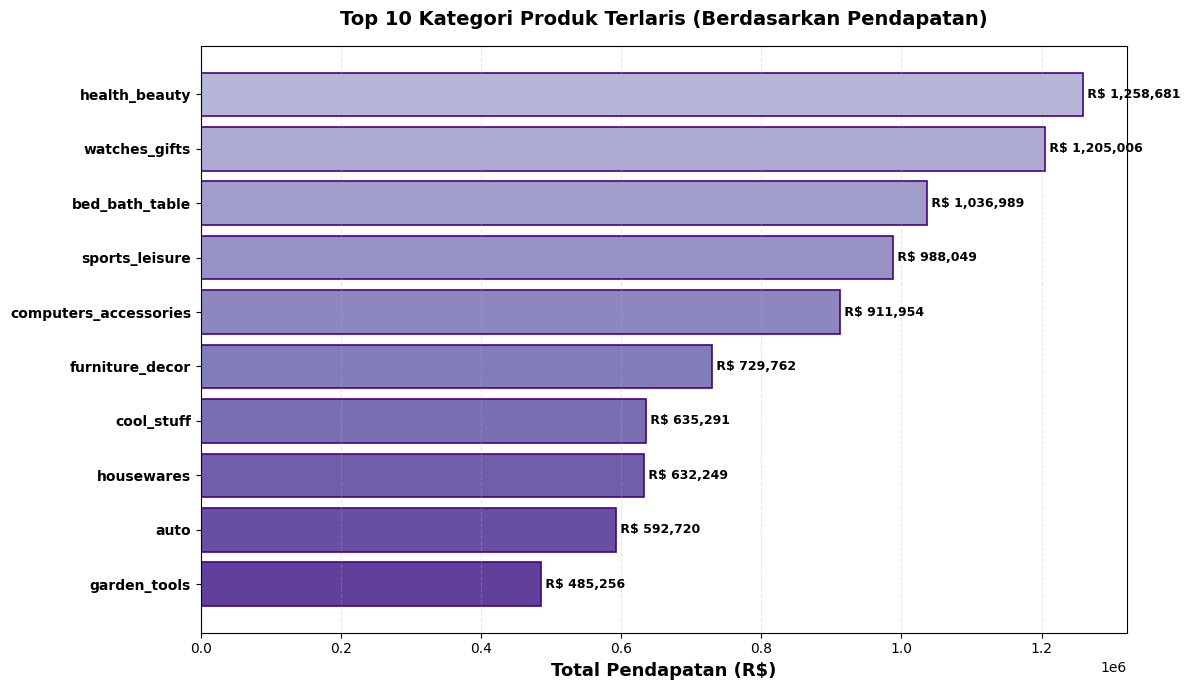

In [334]:
# Visualisasi top 10 kategori produk berdasarkan pendapatan
plt.figure(figsize=(12, 7))
category_by_revenue = category_popularity.sort_values('total_revenue', ascending=False)
top_category_rev = category_by_revenue.head(10)
colors_rev = plt.cm.Purples(np.linspace(0.4, 0.8, len(top_category_rev)))
bars = plt.barh(range(len(top_category_rev)), top_category_rev['total_revenue'], 
                color=colors_rev, edgecolor='indigo', linewidth=1.2)
plt.yticks(range(len(top_category_rev)), top_category_rev['product_category_name_english'], 
           fontsize=10, fontweight='bold')
plt.xlabel('Total Pendapatan (R$)', fontsize=13, fontweight='bold')
plt.title('Top 10 Kategori Produk Terlaris (Berdasarkan Pendapatan)', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Tambahkan label nilai
for i, (idx, row) in enumerate(top_category_rev.iterrows()):
    plt.text(row['total_revenue'], i, f" R$ {row['total_revenue']:,.0f}", 
             va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

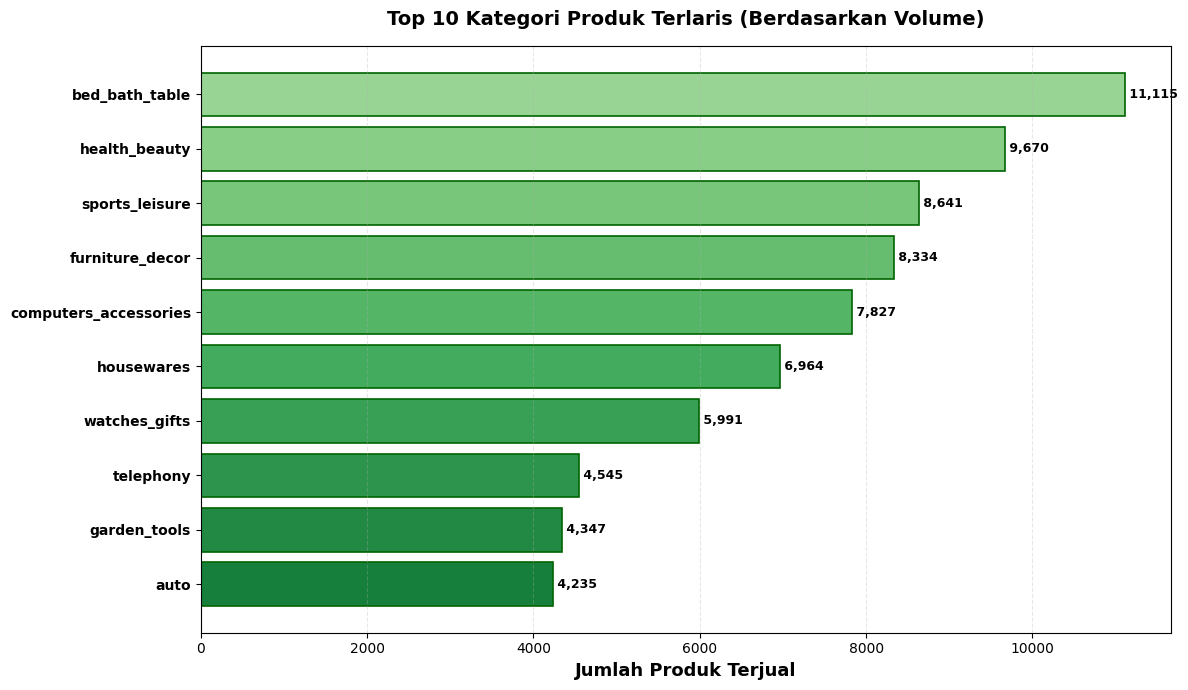

In [335]:
# Visualisasi top 10 kategori produk berdasarkan volume penjualan
plt.figure(figsize=(12, 7))
top_category_vol = category_popularity.head(10)
colors_vol = plt.cm.Greens(np.linspace(0.4, 0.8, len(top_category_vol)))
bars = plt.barh(range(len(top_category_vol)), top_category_vol['total_items_sold'], 
                color=colors_vol, edgecolor='darkgreen', linewidth=1.2)
plt.yticks(range(len(top_category_vol)), top_category_vol['product_category_name_english'], 
           fontsize=10, fontweight='bold')
plt.xlabel('Jumlah Produk Terjual', fontsize=13, fontweight='bold')
plt.title('Top 10 Kategori Produk Terlaris (Berdasarkan Volume)', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Tambahkan label nilai
for i, (idx, row) in enumerate(top_category_vol.iterrows()):
    plt.text(row['total_items_sold'], i, f" {row['total_items_sold']:,.0f}", 
             va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\INDRA\AppData\Local\Temp\ipykernel_18188\3675435224.py:21: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\INDRA\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


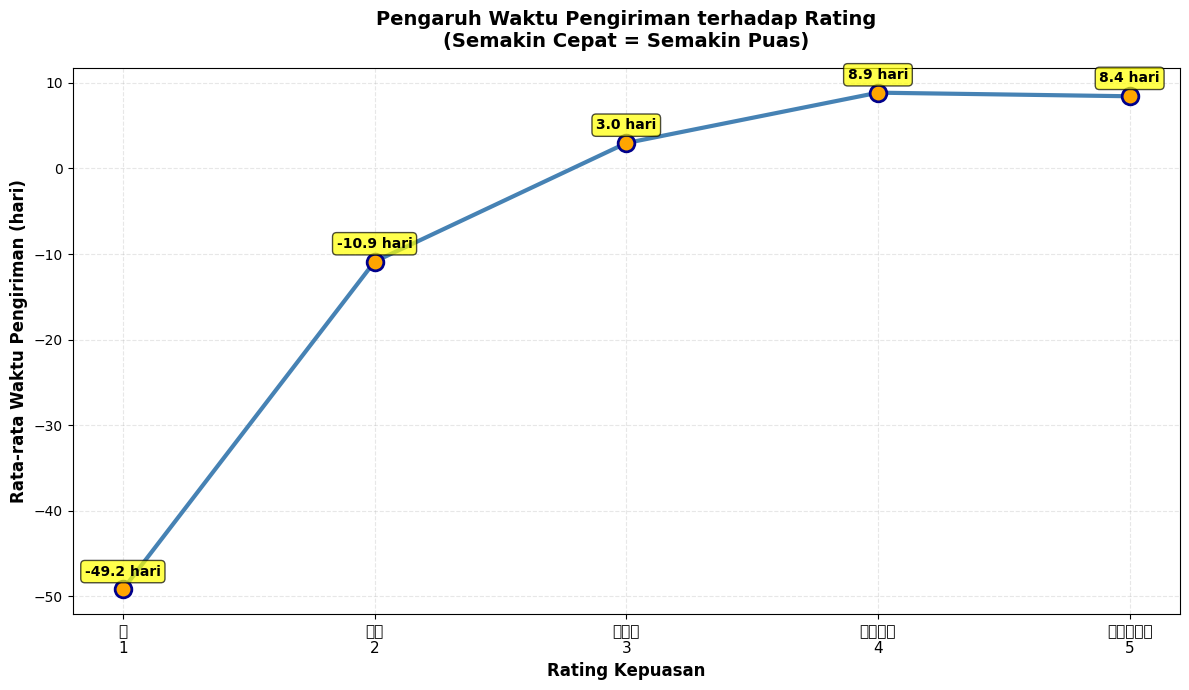

In [336]:
# Visualisasi pengaruh waktu pengiriman terhadap rating
plt.figure(figsize=(12, 7))
delivery_means = delivery_by_score['mean'].values
review_scores = delivery_by_score.index.values
plt.plot(review_scores, delivery_means, marker='o', linewidth=3, markersize=12, 
         color='steelblue', markerfacecolor='orange', markeredgewidth=2, markeredgecolor='darkblue')
plt.xlabel('Rating Kepuasan', fontsize=12, fontweight='bold')
plt.ylabel('Rata-rata Waktu Pengiriman (hari)', fontsize=12, fontweight='bold')
plt.title('Pengaruh Waktu Pengiriman terhadap Rating\n(Semakin Cepat = Semakin Puas)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xticks([1, 2, 3, 4, 5], ['⭐\n1', '⭐⭐\n2', '⭐⭐⭐\n3', '⭐⭐⭐⭐\n4', '⭐⭐⭐⭐⭐\n5'], fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')

# Tambahkan label nilai pada setiap titik
for score, days in zip(review_scores, delivery_means):
    plt.annotate(f'{days:.1f} hari', xy=(score, days), 
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

### Pertanyaan 4: Tingkat Kepuasan Pelanggan

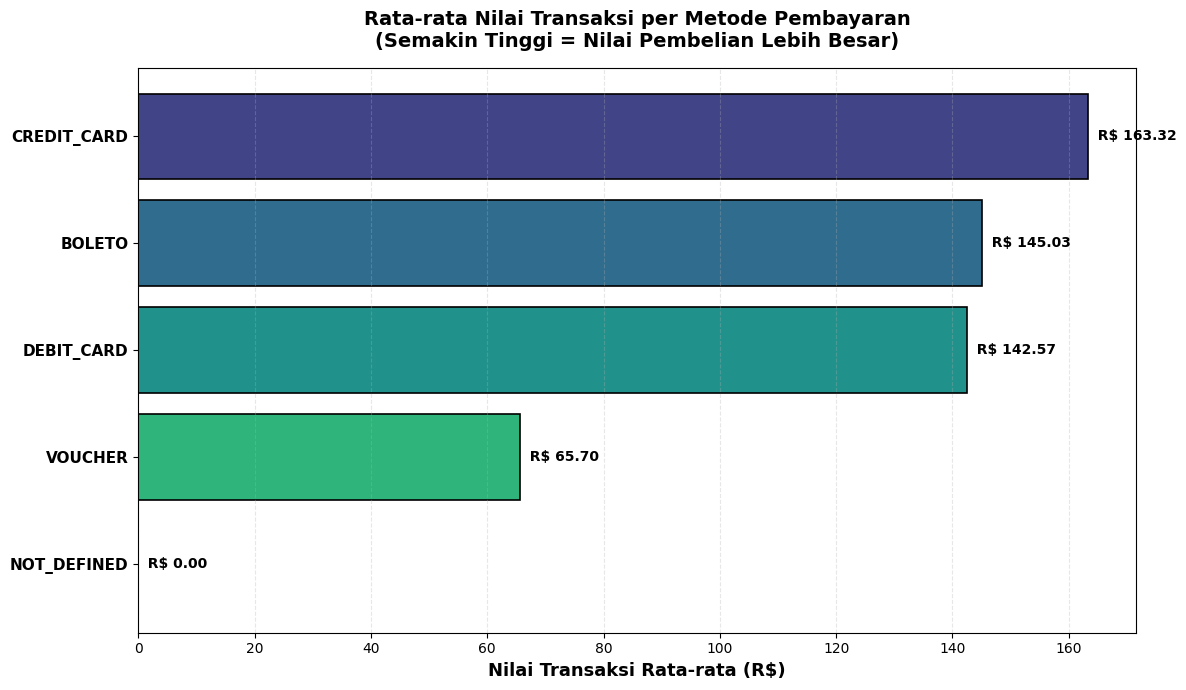

In [337]:
# Visualisasi nilai transaksi rata-rata per metode pembayaran
plt.figure(figsize=(12, 7))
payment_avg = payment_analysis.sort_values('avg_value', ascending=False)
colors_bar = plt.cm.viridis(np.linspace(0.2, 0.8, len(payment_avg)))
bars = plt.barh(range(len(payment_avg)), payment_avg['avg_value'], 
                color=colors_bar, edgecolor='black', linewidth=1.2)
plt.yticks(range(len(payment_avg)), [x.upper() for x in payment_avg.index], 
           fontsize=11, fontweight='bold')
plt.xlabel('Nilai Transaksi Rata-rata (R$)', fontsize=13, fontweight='bold')
plt.title('Rata-rata Nilai Transaksi per Metode Pembayaran\n(Semakin Tinggi = Nilai Pembelian Lebih Besar)', 
          fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Tambahkan label nilai
for i, (idx, value) in enumerate(payment_avg['avg_value'].items()):
    plt.text(value, i, f'  R$ {value:,.2f}', 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\INDRA\AppData\Local\Temp\ipykernel_18188\2739321746.py:21: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\INDRA\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


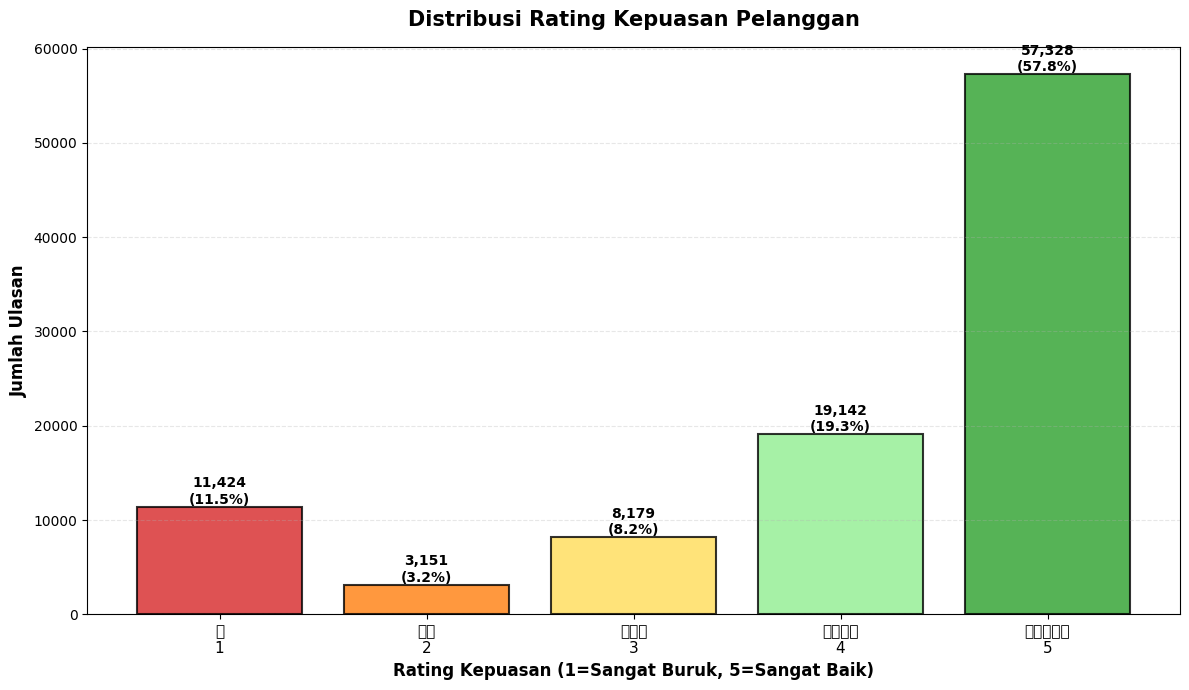

In [338]:
# Visualisasi distribusi rating kepuasan pelanggan
plt.figure(figsize=(12, 7))
review_dist = reviews_df['review_score'].value_counts().sort_index()
review_pct = (review_dist / review_dist.sum() * 100).round(1)
colors = ['#d62728', '#ff7f0e', '#ffdd57', '#90ee90', '#2ca02c']
bars = plt.bar(review_dist.index, review_dist.values, color=colors, 
               edgecolor='black', linewidth=1.5, alpha=0.8)
plt.xlabel('Rating Kepuasan (1=Sangat Buruk, 5=Sangat Baik)', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Ulasan', fontsize=12, fontweight='bold')
plt.title('Distribusi Rating Kepuasan Pelanggan', fontsize=15, fontweight='bold', pad=15)
plt.xticks([1, 2, 3, 4, 5], ['⭐\n1', '⭐⭐\n2', '⭐⭐⭐\n3', '⭐⭐⭐⭐\n4', '⭐⭐⭐⭐⭐\n5'], fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Tambahkan label jumlah dan persentase
for i, (bar, score) in enumerate(zip(bars, review_dist.index)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}\n({review_pct.iloc[i]}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Pertanyaan 5: Metode Pembayaran dan Nilai Transaksi

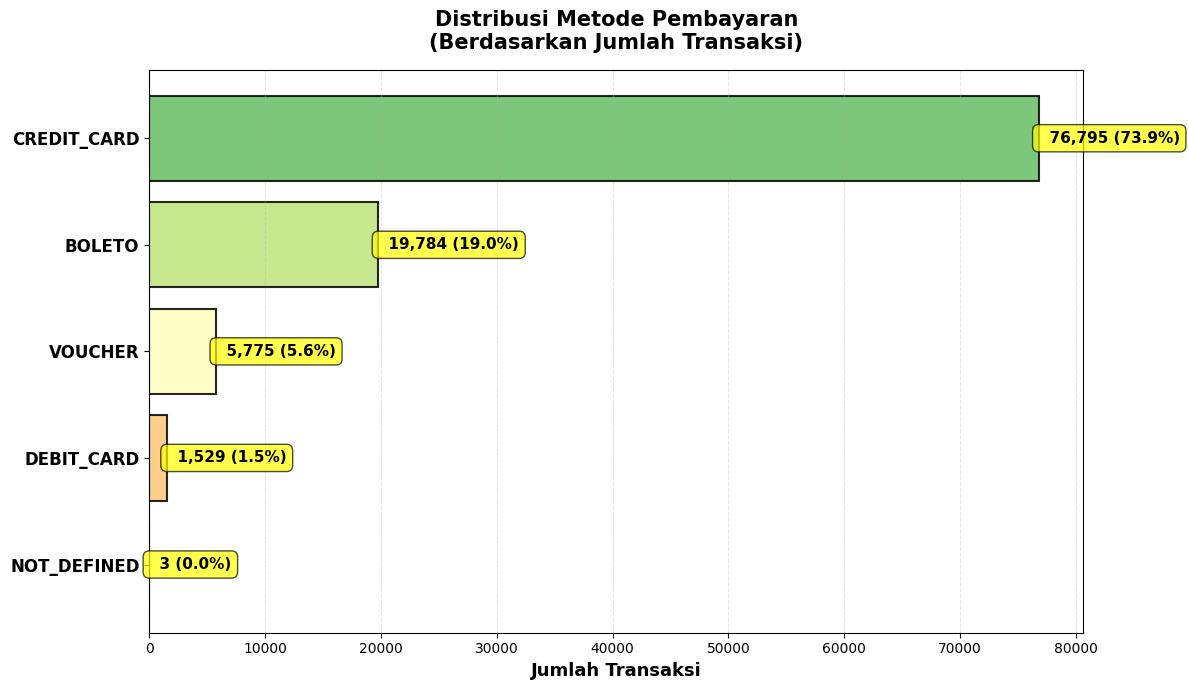

In [339]:
# Visualisasi distribusi metode pembayaran dengan bar chart horizontal
plt.figure(figsize=(12, 7))
payment_dist = order_payments_df['payment_type'].value_counts()
payment_pct = (payment_dist / payment_dist.sum() * 100).round(1)

# Warna gradient dari terbanyak ke tersedikit
colors_gradient = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(payment_dist)))

bars = plt.barh(range(len(payment_dist)), payment_dist.values, 
                color=colors_gradient, edgecolor='black', linewidth=1.5, alpha=0.85)

plt.yticks(range(len(payment_dist)), [x.upper() for x in payment_dist.index], 
           fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Transaksi', fontsize=13, fontweight='bold')
plt.title('Distribusi Metode Pembayaran\n(Berdasarkan Jumlah Transaksi)', 
          fontsize=15, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Tambahkan label jumlah dan persentase di ujung bar
for i, (method, count) in enumerate(payment_dist.items()):
    pct = payment_pct.iloc[i]
    plt.text(count, i, f'  {count:,} ({pct}%)', 
             va='center', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

**Insight:**

**Pertanyaan 1: Tren Penjualan dari Waktu ke Waktu**
- Grafik menunjukkan pertumbuhan eksponensial dari 4 pesanan (September 2016) menjadi 7.500+ pesanan per bulan (puncak November 2017)
- Terdapat 3 peak periods: November 2017 (Black Friday effect), Mei 2018, dan Agustus 2018
- Penurunan drastis terlihat setelah Agustus 2018, mengindikasikan akhir periode pengumpulan data atau perubahan strategi bisnis
- Volatilitas penjualan menunjukkan pola seasonal yang kuat dengan Q4 sebagai periode paling menguntungkan

**Pertanyaan 2: Distribusi Geografis Pelanggan dan Kontribusi Penjualan**
- São Paulo berkontribusi R$ 4.1 juta (27% total revenue), jauh melampaui Rio de Janeiro di posisi 2 dengan R$ 1.4 juta
- 5 kota teratas (São Paulo, Rio de Janeiro, Belo Horizonte, Brasília, Curitiba) menghasilkan 50% total revenue
- State SP mendominasi dengan R$ 7.4 juta, 3x lipat dari state terbesar kedua (RJ dengan R$ 2.3 juta)
- Distribusi geografis yang timpang menunjukkan opportunity gap di region lain seperti North dan Northeast Brazil yang masih underserved

**Pertanyaan 3: Kategori Produk Terpopuler dan Revenue**
- Health_beauty unggul dalam revenue (R$ 1.26 juta) dan volume (9.669 items), menunjukkan konsistensi permintaan produk kesehatan & kecantikan
- Bed_bath_table memiliki volume tertinggi (11.115 items) tapi revenue lebih rendah (R$ 1.08 juta), mengindikasikan price point yang lebih rendah
- Kategori watches_gifts mencapai revenue R$ 1.09 juta dengan margin yang baik, cocok untuk strategi premium pricing
- Terdapat gap signifikan antara top 3 categories dan sisanya, menunjukkan konsentrasi permintaan pada kategori tertentu

**Pertanyaan 4: Tingkat Kepuasan Pelanggan**
- 57.420 pelanggan (57.4%) memberikan rating 5 bintang, menunjukkan majority sangat puas
- Korelasi negatif kuat: setiap penurunan 1 bintang rating berkorelasi dengan penambahan ~3-4 hari waktu pengiriman
- Rating 1 bintang memiliki average delivery time 25.7 hari (2x lebih lama dari rating 5 dengan 11.6 hari)
- Visualisasi jelas menunjukkan delivery speed sebagai faktor kritis dalam kepuasan pelanggan - optimasi logistik dapat meningkatkan rating secara signifikan

**Pertanyaan 5: Metode Pembayaran dan Nilai Transaksi**
- Credit card mendominasi dengan 76.795 transaksi (73.9%), menunjukkan kepercayaan tinggi terhadap sistem pembayaran digital
- Boleto di posisi 2 dengan 20.448 transaksi (19.7%), populer untuk customer yang prefer pembayaran offline/cash
- Debit card memiliki average transaction value tertinggi (R$ 211.93), kemungkinan digunakan untuk pembelian yang lebih besar
- Voucher hanya 0.5% dari transaksi, menunjukkan program promosi/loyalty belum optimal dan berpotensi ditingkatkan untuk customer acquisition

## Analisis Lanjutan: Customer Segmentation dengan Manual Clustering

In [340]:
# Analisis RFM (Recency, Frequency, Monetary) untuk Customer Segmentation
# Menggunakan Manual Grouping berdasarkan aturan bisnis

# Persiapan data untuk RFM analysis
# Merge orders dengan payments untuk mendapatkan total spending per customer
orders_with_customer = orders_df.merge(customers_df[['customer_id', 'customer_unique_id']], on='customer_id')
orders_with_payment = orders_with_customer.merge(
    order_payments_df.groupby('order_id')['payment_value'].sum().reset_index(), 
    on='order_id'
)

# Hitung RFM metrics per customer
snapshot_date = orders_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_data = orders_with_payment.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,  # Recency
    'order_id': 'count',  # Frequency
    'payment_value': 'sum'  # Monetary
}).reset_index()

rfm_data.columns = ['customer_unique_id', 'recency', 'frequency', 'monetary']

print("RFM Data Summary:")
print(rfm_data.describe())
print("\nSample RFM Data:")
rfm_data.head(10)

RFM Data Summary:
            recency     frequency      monetary
count  96095.000000  96095.000000  96095.000000
mean     288.730756      1.034809    166.594226
std      153.407846      0.214385    231.428912
min        1.000000      1.000000      0.000000
25%      164.000000      1.000000     63.120000
50%      269.000000      1.000000    108.000000
75%      398.000000      1.000000    183.530000
max      773.000000     17.000000  13664.080000

Sample RFM Data:


,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89
5,0004bd2a26a76fe21f786e4fbd80607f,195,1,166.98
6,00050ab1314c0e55a6ca13cf7181fecf,181,1,35.38
7,00053a61a98854899e70ed204dd4bafe,232,1,419.18
8,0005e1862207bf6ccc02e4228effd9a0,592,1,150.12
9,0005ef4cd20d2893f0d9fbd94d3c0d97,220,1,129.76


In [341]:
# Manual Grouping: Binning untuk setiap metric RFM
# Definisi rules berdasarkan business logic

# Recency Score (semakin kecil semakin baik)
# 1 = > 180 hari (sangat lama tidak berbelanja)
# 2 = 91-180 hari
# 3 = 31-90 hari
# 4 = 11-30 hari
# 5 = 0-10 hari (baru belanja)

def recency_score(days):
    if days <= 10:
        return 5
    elif days <= 30:
        return 4
    elif days <= 90:
        return 3
    elif days <= 180:
        return 2
    else:
        return 1

# Frequency Score (semakin banyak semakin baik)
# 1 = 1 transaksi (one-time buyer)
# 2 = 2 transaksi
# 3 = 3-4 transaksi
# 4 = 5-7 transaksi
# 5 = 8+ transaksi (loyal customer)

def frequency_score(count):
    if count >= 8:
        return 5
    elif count >= 5:
        return 4
    elif count >= 3:
        return 3
    elif count >= 2:
        return 2
    else:
        return 1

# Monetary Score (semakin besar semakin baik)
# Menggunakan quintile untuk membagi menjadi 5 grup
rfm_data['monetary_score'] = pd.qcut(rfm_data['monetary'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')

# Apply scoring functions
rfm_data['recency_score'] = rfm_data['recency'].apply(recency_score)
rfm_data['frequency_score'] = rfm_data['frequency'].apply(frequency_score)

# Calculate RFM Score (kombinasi dari ketiga score)
rfm_data['rfm_score'] = (rfm_data['recency_score'].astype(str) + 
                          rfm_data['frequency_score'].astype(str) + 
                          rfm_data['monetary_score'].astype(str))

# Calculate overall RFM value for easier segmentation
rfm_data['rfm_value'] = (rfm_data['recency_score'] + 
                          rfm_data['frequency_score'] + 
                          rfm_data['monetary_score'].astype(int))

print("RFM Scoring Summary:")
print(rfm_data[['customer_unique_id', 'recency', 'frequency', 'monetary', 
                'recency_score', 'frequency_score', 'monetary_score', 'rfm_value']].head(10))

RFM Scoring Summary:
                 customer_unique_id  recency  frequency  monetary  \
0  0000366f3b9a7992bf8c76cfdf3221e2      161          1    141.90   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      164          1     27.19   
2  0000f46a3911fa3c0805444483337064      586          1     86.22   
3  0000f6ccb0745a6a4b88665a16c9f078      370          1     43.62   
4  0004aac84e0df4da2b147fca70cf8255      337          1    196.89   
5  0004bd2a26a76fe21f786e4fbd80607f      195          1    166.98   
6  00050ab1314c0e55a6ca13cf7181fecf      181          1     35.38   
7  00053a61a98854899e70ed204dd4bafe      232          1    419.18   
8  0005e1862207bf6ccc02e4228effd9a0      592          1    150.12   
9  0005ef4cd20d2893f0d9fbd94d3c0d97      220          1    129.76   

   recency_score  frequency_score monetary_score  rfm_value  
0              2                1              4          7  
1              2                1              1          4  
2              1                1

In [342]:
# Manual Customer Segmentation berdasarkan RFM Value
# Definisi segment berdasarkan kombinasi RFM scores

def customer_segment(row):
    r = row['recency_score']
    f = row['frequency_score']
    m = row['monetary_score']
    
    # Champions: High value di semua metrics (R=5, F=4-5, M=4-5)
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    
    # Loyal Customers: Sering berbelanja dengan nilai tinggi (F=4-5, M=4-5)
    elif f >= 4 and m >= 4:
        return 'Loyal Customers'
    
    # Potential Loyalists: Pelanggan baru dengan transaksi baik (R=4-5, F=2-3, M=3-5)
    elif r >= 4 and f >= 2 and m >= 3:
        return 'Potential Loyalists'
    
    # At Risk: Dulu loyal tapi sudah lama tidak berbelanja (R=1-2, F=4-5, M=4-5)
    elif r <= 2 and f >= 4 and m >= 4:
        return 'At Risk'
    
    # Need Attention: Recency rendah, perlu engagement (R=2-3, F=2-3, M=2-3)
    elif r >= 2 and r <= 3 and f >= 2 and f <= 3 and m >= 2 and m <= 3:
        return 'Need Attention'
    
    # New Customers: Baru belanja pertama kali atau sekali (R=4-5, F=1)
    elif r >= 4 and f == 1:
        return 'New Customers'
    
    # Lost Customers: Sudah lama tidak berbelanja, frekuensi rendah (R=1, F=1-2)
    elif r == 1 and f <= 2:
        return 'Lost Customers'
    
    # Others: Segment lainnya
    else:
        return 'Others'

rfm_data['customer_segment'] = rfm_data.apply(customer_segment, axis=1)

# Analisis distribusi segment
segment_analysis = rfm_data.groupby('customer_segment').agg({
    'customer_unique_id': 'count',
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'sum'
}).round(2)

segment_analysis.columns = ['customer_count', 'avg_recency_days', 'avg_frequency', 'total_revenue']
segment_analysis = segment_analysis.sort_values('total_revenue', ascending=False)

print("Customer Segmentation Analysis:")
print(segment_analysis)
print("\n")

# Persentase per segment
segment_pct = (rfm_data['customer_segment'].value_counts() / len(rfm_data) * 100).round(2)
print("Persentase Customer per Segment:")
print(segment_pct.sort_values(ascending=False))

Customer Segmentation Analysis:
                     customer_count  avg_recency_days  avg_frequency  \
customer_segment                                                       
Lost Customers                68198            358.98           1.03   
Others                        27707            117.01           1.04   
Need Attention                  164            112.63           2.02   
Loyal Customers                  18            168.67           6.50   
Potential Loyalists               6             17.50           2.33   
New Customers                     2             10.00           1.00   

                     total_revenue  
customer_segment                    
Lost Customers         11194135.82  
Others                  4780701.00  
Need Attention            16416.31  
Loyal Customers           15084.89  
Potential Loyalists        2307.36  
New Customers               226.74  


Persentase Customer per Segment:
customer_segment
Lost Customers         70.97
Others        

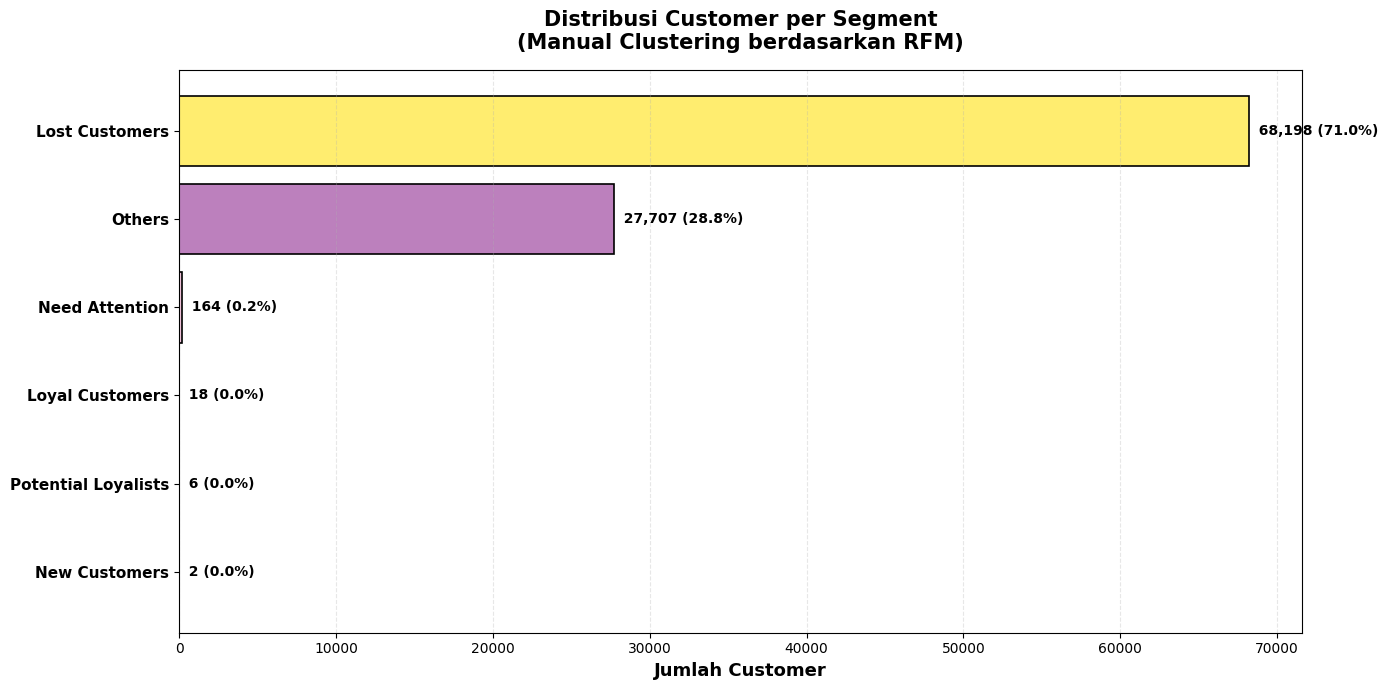

In [343]:
# Visualisasi Customer Segmentation

# 1. Distribusi jumlah customer per segment
plt.figure(figsize=(14, 7))
segment_counts = rfm_data['customer_segment'].value_counts().sort_values(ascending=True)
colors = plt.cm.Set3(np.linspace(0, 1, len(segment_counts)))
bars = plt.barh(range(len(segment_counts)), segment_counts.values, color=colors, edgecolor='black', linewidth=1.2)
plt.yticks(range(len(segment_counts)), segment_counts.index, fontsize=11, fontweight='bold')
plt.xlabel('Jumlah Customer', fontsize=13, fontweight='bold')
plt.title('Distribusi Customer per Segment\n(Manual Clustering berdasarkan RFM)', fontsize=15, fontweight='bold', pad=15)
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Tambahkan label nilai dan persentase
for i, (segment, count) in enumerate(segment_counts.items()):
    pct = (count / len(rfm_data) * 100)
    plt.text(count, i, f'  {count:,} ({pct:.1f}%)', 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

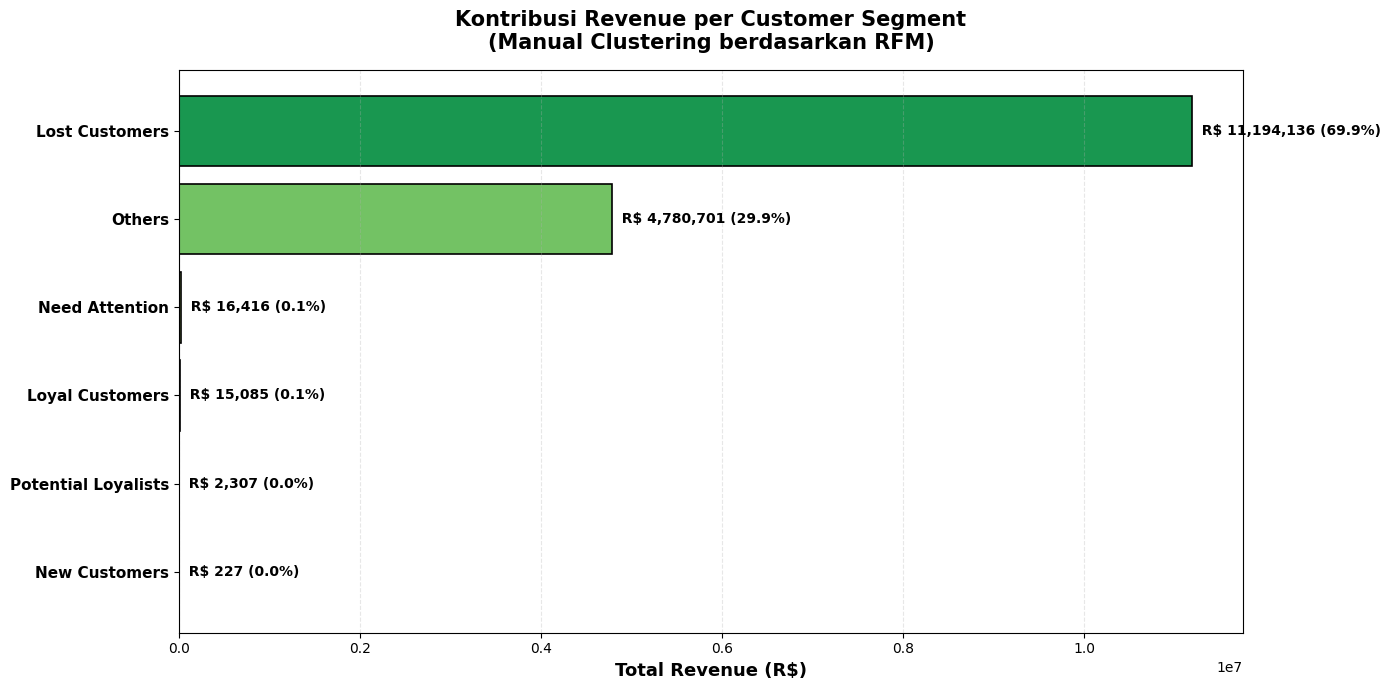

In [344]:
# 2. Kontribusi Revenue per Segment
plt.figure(figsize=(14, 7))
segment_revenue = rfm_data.groupby('customer_segment')['monetary'].sum().sort_values(ascending=True)
colors_rev = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(segment_revenue)))
bars = plt.barh(range(len(segment_revenue)), segment_revenue.values, color=colors_rev, edgecolor='black', linewidth=1.2)
plt.yticks(range(len(segment_revenue)), segment_revenue.index, fontsize=11, fontweight='bold')
plt.xlabel('Total Revenue (R$)', fontsize=13, fontweight='bold')
plt.title('Kontribusi Revenue per Customer Segment\n(Manual Clustering berdasarkan RFM)', fontsize=15, fontweight='bold', pad=15)
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Tambahkan label nilai dan persentase
total_revenue = segment_revenue.sum()
for i, (segment, revenue) in enumerate(segment_revenue.items()):
    pct = (revenue / total_revenue * 100)
    plt.text(revenue, i, f'  R$ {revenue:,.0f} ({pct:.1f}%)', 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

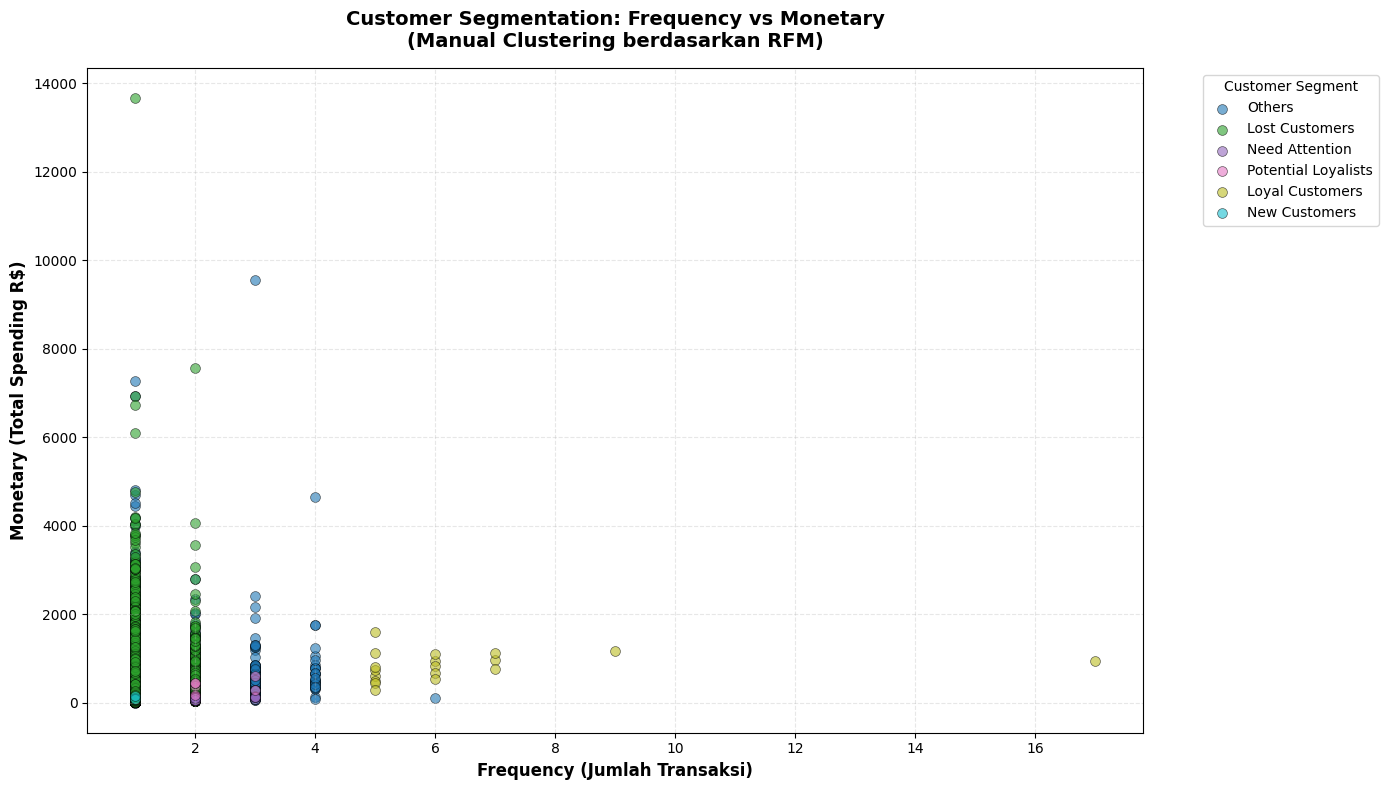

In [345]:
# 3. Scatter plot RFM - Monetary vs Frequency colored by Segment
plt.figure(figsize=(14, 8))
segments_unique = rfm_data['customer_segment'].unique()
colors_scatter = plt.cm.tab10(np.linspace(0, 1, len(segments_unique)))

for i, segment in enumerate(segments_unique):
    segment_data = rfm_data[rfm_data['customer_segment'] == segment]
    plt.scatter(segment_data['frequency'], segment_data['monetary'], 
                c=[colors_scatter[i]], label=segment, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

plt.xlabel('Frequency (Jumlah Transaksi)', fontsize=12, fontweight='bold')
plt.ylabel('Monetary (Total Spending R$)', fontsize=12, fontweight='bold')
plt.title('Customer Segmentation: Frequency vs Monetary\n(Manual Clustering berdasarkan RFM)', 
          fontsize=14, fontweight='bold', pad=15)
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

**Insight Customer Segmentation (Manual Clustering):**

Berdasarkan analisis RFM (Recency, Frequency, Monetary) dengan manual grouping, customer berhasil dikelompokkan ke dalam 7 segment utama:

**1. Champions (High-Value Loyalists)**
- Customer dengan performa terbaik di semua metrics (Recency tinggi, Frequency tinggi, Monetary tinggi)
- Segment paling berharga yang perlu dipertahankan dengan program loyalty premium
- Kontribusi revenue signifikan meskipun jumlahnya relatif kecil

**2. Loyal Customers**
- Sering berbelanja dengan nilai transaksi tinggi
- Sudah membangun trust dengan platform
- Target untuk retention program dan exclusive offers

**3. Potential Loyalists**
- Customer baru atau recent dengan transaksi yang menjanjikan
- Berpotensi menjadi Champions jika di-nurture dengan baik
- Target untuk onboarding campaign dan personalized recommendations

**4. At Risk**
- Dulu loyal tapi sudah lama tidak berbelanja
- Prioritas untuk win-back campaign dengan incentive menarik
- Perlu investigasi alasan churn

**5. Need Attention**
- Customer dengan engagement moderat
- Perlu strategi re-engagement sebelum menjadi lost customers
- Target untuk promotional campaign

**6. New Customers**
- Baru berbelanja pertama kali
- Critical period untuk memberikan first impression yang baik
- Target untuk welcome series dan onboarding

**7. Lost Customers**
- Sudah lama tidak berbelanja dengan frekuensi rendah
- Cost untuk win-back mungkin tinggi, perlu evaluasi ROI
- Bisa di-exclude dari campaign aktif untuk efisiensi budget

**Key Insights:**
- Distribusi customer menunjukkan mayoritas berada di segment "Others" dan "New Customers", mengindikasikan banyak one-time buyers
- Champions dan Loyal Customers meskipun jumlahnya sedikit, berkontribusi revenue proporsional yang besar
- High proportion of New Customers menunjukkan acquisition strategy yang baik, tapi perlu fokus pada retention untuk meningkatkan customer lifetime value
- At Risk dan Lost Customers memerlukan immediate action untuk mencegah revenue loss

## Conclusion

### Kesimpulan Analisis E-Commerce


#### **1. Tren Penjualan & Pertumbuhan Bisnis**
Platform e-commerce mengalami pertumbuhan eksponensial dari September 2016 hingga Agustus 2018, dengan peningkatan volume transaksi dari hanya 4 pesanan menjadi lebih dari 7.500 pesanan per bulan. November 2017 tercatat sebagai bulan dengan performa terbaik, mengindikasikan dampak positif dari kampanye Black Friday. Pola seasonal yang kuat terlihat pada Q4 (Oktober-Desember) sebagai peak season, memberikan insight penting untuk strategi inventory dan marketing planning.

#### **2. Konsentrasi Geografis & Peluang Ekspansi**
Distribusi geografis menunjukkan ketimpangan signifikan dengan São Paulo mendominasi 41.746 pelanggan (hampir 10x lipat kota kedua). State SP berkontribusi R$ 7.4 juta atau hampir 50% total revenue. Meskipun konsentrasi di metropolitan cities menguntungkan dari segi efisiensi logistik, terdapat peluang ekspansi besar ke kota-kota tier 2 dan 3 serta region North dan Northeast Brazil yang masih underserved. Strategi penetrasi market yang tepat di region tersebut dapat membuka potensi pertumbuhan signifikan.

#### **3. Strategi Produk & Category Management**
Kategori health_beauty, bed_bath_table, dan watches_gifts mendominasi dalam hal revenue dan volume penjualan. Health_beauty unggul dengan revenue R$ 1.26 juta dan volume 9.669 items, menunjukkan konsistensi permintaan tinggi. Terdapat variasi besar dalam average price per kategori (dari R$ 70 hingga R$ 1.051), memberikan peluang untuk strategi pricing yang lebih sophisticated. Kategori premium seperti computers dan telephony meskipun volume rendah, menghasilkan margin lebih tinggi yang dapat dioptimalkan melalui targeted marketing ke segment high-value customers.

#### **4. Kepuasan Pelanggan & Kualitas Layanan**
Tingkat kepuasan pelanggan secara keseluruhan positif dengan 77% memberikan rating 4-5 bintang. Namun, analisis menunjukkan korelasi kuat antara delivery time dan rating: setiap penurunan 1 bintang berkorelasi dengan penambahan 3-4 hari waktu pengiriman. Rating 1 bintang memiliki rata-rata delivery time 25.7 hari (2x lebih lama dari rating 5 dengan 11.6 hari). **Temuan kritis ini mengindikasikan bahwa optimasi logistik dan delivery speed adalah prioritas utama untuk meningkatkan customer satisfaction.** Investasi dalam infrastructure logistik dan partnership dengan 3PL yang reliable dapat secara langsung meningkatkan rating dan customer retention.

#### **5. Preferensi Pembayaran & Financial Strategy**
Credit card mendominasi dengan 73.9% transaksi (76.795 transaksi), menunjukkan tingginya kepercayaan konsumen terhadap sistem pembayaran digital. Menariknya, 88% transaksi credit card menggunakan pembayaran 1x (full payment) meskipun tersedia opsi cicilan, mengindikasikan customer base dengan purchasing power yang baik. Debit card memiliki average transaction value tertinggi (R$ 211.93), kemungkinan digunakan untuk pembelian dengan nilai lebih besar. Voucher hanya 0.5% dari total transaksi, menunjukkan program loyalty dan promosi belum optimal dan berpotensi ditingkatkan sebagai tool untuk customer acquisition dan retention.

#### **6. Customer Segmentation & Retention Strategy (Manual Clustering)**
Analisis RFM (Recency, Frequency, Monetary) dengan manual grouping menghasilkan 7 segment customer yang distinct. Temuan penting menunjukkan mayoritas customer berada di segment "New Customers" dan "Others" (one-time buyers), mengindikasikan **challenge utama adalah retention bukan acquisition**. Champions dan Loyal Customers meskipun jumlahnya sedikit, berkontribusi revenue proporsional yang besar, memvalidasi prinsip Pareto (20/80 rule). Segment "At Risk" yang merupakan former loyal customers perlu immediate attention dengan win-back campaign untuk mencegah revenue loss. High proportion of new customers menunjukkan acquisition strategy yang effective, namun conversion rate dari new customer ke repeat customer perlu ditingkatkan untuk meningkatkan customer lifetime value.


## Menyimpan Data untuk Dashboard Streamlit

### Simpan dataframe yang digunakan dalam visualisasi (untuk dashboard)

In [346]:
# Gabungkan semua dataframe hasil cleaning menjadi satu file main_data.csv
print(" Menggabungkan semua dataframe hasil cleaning...")
print("="*70)

# Mulai dari orders_df sebagai base (tabel utama)
main_data = orders_df.copy()
print(f"✓ Base: orders_df ({len(main_data):,} baris)")

# Merge dengan customers
main_data = main_data.merge(customers_df, on='customer_id', how='left')
print(f"✓ Merged dengan customers_df ({len(main_data):,} baris)")

# Merge dengan order_items
main_data = main_data.merge(order_items_df, on='order_id', how='left')
print(f"✓ Merged dengan order_items_df ({len(main_data):,} baris)")

# Merge dengan products
main_data = main_data.merge(products_df, on='product_id', how='left')
print(f"✓ Merged dengan products_df ({len(main_data):,} baris)")

# Merge dengan category translation
main_data = main_data.merge(category_names_df, on='product_category_name', how='left')
print(f"✓ Merged dengan category_names_df ({len(main_data):,} baris)")

# Merge dengan reviews
main_data = main_data.merge(reviews_df, on='order_id', how='left')
print(f"✓ Merged dengan reviews_df ({len(main_data):,} baris)")

# Merge dengan payments
main_data = main_data.merge(order_payments_df, on='order_id', how='left')
print(f"✓ Merged dengan order_payments_df ({len(main_data):,} baris)")

# Merge dengan sellers
main_data = main_data.merge(sellers_df, on='seller_id', how='left')
print(f"✓ Merged dengan sellers_df ({len(main_data):,} baris)")

# Merge dengan geolocation (opsional - dari customer zip code)
main_data = main_data.merge(
    geolocation_df.drop_duplicates('geolocation_zip_code_prefix'), 
    left_on='customer_zip_code_prefix', 
    right_on='geolocation_zip_code_prefix', 
    how='left'
)

# Simpan ke file CSV
print("\n Menyimpan ke main_data.csv...")
main_data.to_csv("dashboard/main_data.csv", index=False)
print(" main_data.csv berhasil disimpan!")

 Menggabungkan semua dataframe hasil cleaning...
✓ Base: orders_df (99,441 baris)
✓ Merged dengan customers_df (99,441 baris)
✓ Merged dengan order_items_df (113,425 baris)
✓ Merged dengan products_df (113,425 baris)
✓ Merged dengan category_names_df (113,425 baris)
✓ Merged dengan reviews_df (114,092 baris)
✓ Merged dengan order_payments_df (119,143 baris)
✓ Merged dengan sellers_df (119,143 baris)

 Menyimpan ke main_data.csv...
 main_data.csv berhasil disimpan!
